In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv('encuesta.csv')

print("Columnas:")
for i, c in enumerate(df.columns):
    print(f"{i}: {c}")

Columnas:
0: ID
1: Tu Semestre Actual
2: Eres originario de Guadalupe Victoria?
3: El Tecnológico de los Llanos fue tu:
4: ¿Por qué elegiste esta institución? (elige máximo 3)
5: Si no fue tu primera opción, ¿cuál fue el motivo principal?
6: Ingeniería Mecatrónica fue tu:
7: Motivo principal para elegir Mecatrónica 
8: Antes de ingresar, tu conocimiento sobre la carrera era:
9: Percepcion de Calidad académica general de la carrera
10: Como consideras el nivel de los docentes
11: Preparación técnica que estás recibiendo
12: Actualización tecnológica de contenidos
13: Uso de laboratorios y prácticas
14: Vinculación con industria
15: ¿Qué deberían mejorar los docentes? (máximo 2)
16: Como sientes el Nivel de exigencia académica actual:
17: Participación en concursos de robótica/tecnología
18: Participación en proyectos de investigación
19: Que tan importante es para ti los Deportes institucionales
20: Que tan importante es para ti las Actividades culturales
21: Que tan importante es para 

In [4]:
mapa = {
    13: "uso de laboratorio y practicas",
    14: "Vínculo con el sector productivo"
}

df = df.rename(columns={df.columns[i]: nuevo for i, nuevo in mapa.items()})
print(df.columns.tolist())
df.head()

['ID', 'Tu Semestre Actual', 'Eres originario de Guadalupe Victoria?', 'El Tecnológico de los Llanos fue tu:', '¿Por qué elegiste esta institución? (elige máximo 3)', 'Si no fue tu primera opción, ¿cuál fue el motivo principal?', 'Ingeniería Mecatrónica fue tu:', 'Motivo principal para elegir Mecatrónica\xa0', 'Antes de ingresar, tu conocimiento sobre la carrera era:', 'Percepcion de Calidad académica general de la carrera', 'Como consideras el nivel de los docentes', 'Preparación técnica que estás recibiendo', 'Actualización tecnológica de contenidos', 'uso de laboratorio y practicas', 'Vínculo con el sector productivo', '¿Qué deberían mejorar los docentes? (máximo 2)', 'Como sientes el Nivel de exigencia académica actual:', 'Participación en concursos de robótica/tecnología', 'Participación en proyectos de investigación', 'Que tan importante es para ti los Deportes institucionales', 'Que tan importante es para ti las Actividades culturales', 'Que tan importante es para ti los Clubes 

,ID,Tu Semestre Actual,Eres originario de Guadalupe Victoria?,El Tecnológico de los Llanos fue tu:,¿Por qué elegiste esta institución? (elige máximo 3),"Si no fue tu primera opción, ¿cuál fue el motivo principal?",Ingeniería Mecatrónica fue tu:,Motivo principal para elegir Mecatrónica,"Antes de ingresar, tu conocimiento sobre la carrera era:",Percepcion de Calidad académica general de la carrera,...,Participación en concursos de robótica/tecnología,Participación en proyectos de investigación,Que tan importante es para ti los Deportes institucionales,Que tan importante es para ti las Actividades culturales,Que tan importante es para ti los Clubes estudiantiles,¿Has participado en alguna actividad extracurricular?,"Si no participas, el motivo principal es:",¿Has pensado en dejar la carrera?,Motivos que podrían llevarte a dejar la carrera (máximo 3):,Nivel de satisfacción general con la carrera:
0,1,8°,Si,2da opcion,Cercanía a mi domicilio;Recomendación de famil...,Decisión familiar,1er opción,Interés en Electrónica,Poco Claro,Buena,...,Importante,Algo Importante,Algo Importante,Importante,Importante,Si,NaN,Una vez,Falta de motivación,Satisfecho
1,2,8°,No,1er opcion,Cercanía a mi domicilio;Costo accesible;Recome...,No aplica,2da opción,Campo laboral ampli,Poco Claro,Buena,...,Importante,Algo Importante,Algo Importante,Algo Importante,Muy Importante,No,NaN,NaN,Estrés o carga excesiva,Satisfecho
2,3,8°,No,1er opcion,Cercanía a mi domicilio;Recomendación de famil...,No aplica,1er opción,Interés en Electrónica,Poco Claro,Buena,...,Importante,Muy Importante,Importante,Muy Importante,Importante,Si,NaN,Nunca,Problemas económicos,Satisfecho
3,4,8°,No,2da opcion,Cercanía a mi domicilio;,Cambié de interes,1er opción,Interés en Robótica,Poco Claro,Excelente,...,Importante,Importante,Algo Importante,Algo Importante,Importante,No,NaN,NaN,Problemas personales,Satisfecho
4,5,8°,Si,3er opción o más,Otra;,Motivos económicos,1er opción,Interés en Electrónica,Muy Limitado,Buena,...,Muy Importante,Muy Importante,Importante,Importante,Importante,Si,NaN,Nunca,Cambio de intereses,Neutral


In [5]:
shape = df.shape
null_counts = df.isna().sum()
null_pct = (null_counts / len(df) * 100).round(2)
non_null = df.notna().sum()
dtypes = df.dtypes.astype(str)

In [6]:
samples = []
for col in df.columns:
    vals = df[col].dropna().unique()
    vals = vals[:3]
    samples.append(", ".join(str(v) for v in vals))

summary = pd.DataFrame({
    "columna": df.columns,
    "tipo": dtypes.values,
    "no_nulos": non_null.values,
    "nulos": null_counts.values,
    "%_nulos": null_pct.values,
    "ejemplos": samples
}).sort_values(["nulos", "%_nulos"], ascending=False).reset_index(drop=True)

In [7]:
print(summary.head(10).to_string(index=False))

                                                    columna  tipo  no_nulos  nulos  %_nulos                                                                                                                                                                                                                         ejemplos
                  Si no participas, el motivo principal es:   str        44     38    46.34                                                                                                                                                                                         Trabajo, Falta de tiempo, No me interesa
                          ¿Has pensado en dejar la carrera?   str        64     18    21.95                                                                                                                                                                                                     Una vez, Nunca, Varias veces
 Que tan importante es para ti los Deportes insti

In [8]:
idx = [23, 24, 19]  # <-- lista de índices a limpiar

for i in idx:
    df.iloc[:, i] = df.iloc[:, i].fillna("No aplica")

print(df.iloc[:, idx].isna().sum())

Si no participas, el motivo principal es:                     0
¿Has pensado en dejar la carrera?                             0
Que tan importante es para ti los Deportes institucionales    0
dtype: int64


In [9]:
df.to_csv("encuesta_limpia.csv", index=False, encoding="utf-8-sig")
df = pd.read_csv("encuesta_limpia.csv")

In [10]:
# conteo
sem = df.iloc[:, 1]
counts = sem.value_counts().sort_index()
print(counts)

Tu Semestre Actual
2°    24
4°    23
6°    17
8°    18
Name: count, dtype: int64


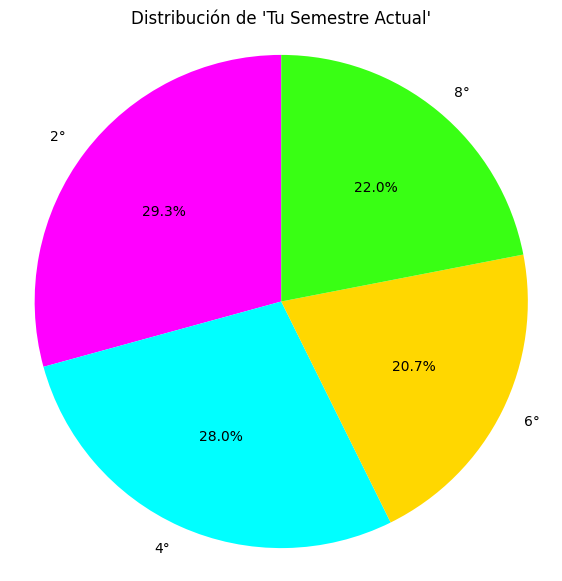

In [11]:
import matplotlib.pyplot as plt 
# Gráfica de pie
plt.figure(figsize=(7, 7))

colores = ['#FF00FF',  # fucsia eléctrico
           '#00FFFF',  # cian brillante
           '#FFD700',  # dorado
           '#39FF14']  # verde neón

plt.pie(counts.values, 
        labels=counts.index, 
        autopct='%1.1f%%', 
        startangle=90,
        colors=colores)

plt.title("Distribución de 'Tu Semestre Actual'")
plt.axis('equal')  # mantiene el círculo
plt.show()


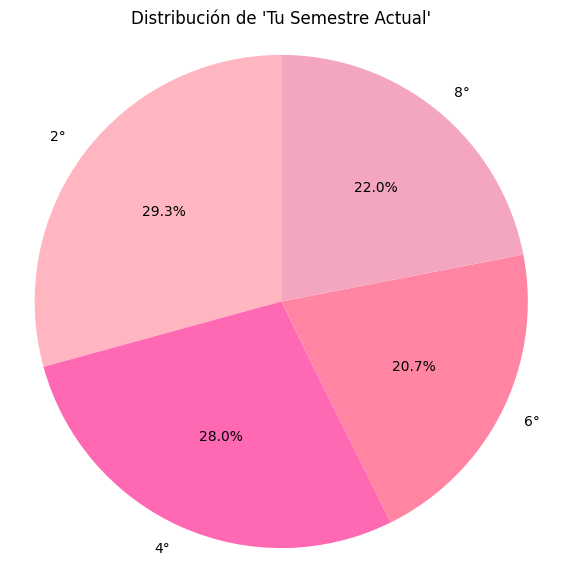

In [12]:
import matplotlib.pyplot as plt

# Colores en tonos rosa
colores = ["#ffb6c1", "#ff69b4", "#ff85a2", "#f4a6c1"]

# Gráfica de pie
plt.figure(figsize=(7, 7))
plt.pie(counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colores)

plt.title("Distribución de 'Tu Semestre Actual'")
plt.axis('equal')  # mantiene el círculo
plt.show()

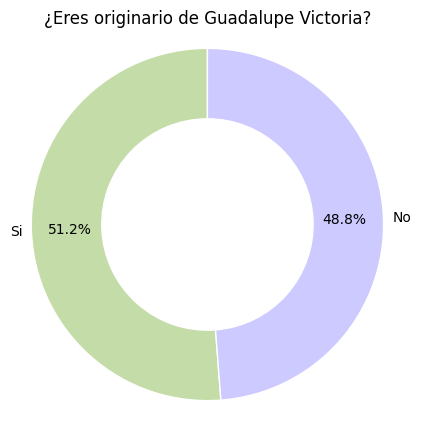

In [13]:
serie = df.iloc[:, 2].astype(str).str.strip()
serie = serie.replace({"nan": pd.NA}).dropna()

counts = serie.value_counts()

plt.figure(figsize=(5,5))
wedges, texts, autotexts = plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#c4dca8", "#cdcaff"],  # azul pastel y rosa pastel
    wedgeprops=dict(width=0.40, edgecolor="white"),  # dona
    pctdistance=0.78,
    labeldistance=1.05
)

plt.title("¿Eres originario de Guadalupe Victoria?")
plt.axis("equal")
plt.show()

In [14]:
tmp = df.iloc[:, [1, 2]].copy()
tmp.iloc[:, 0] = tmp.iloc[:, 0].astype(str).str.strip()  # semestre
tmp.iloc[:, 1] = tmp.iloc[:, 1].astype(str).str.strip()  # Sí/No GV

# Tabla: filas=semestre, columnas=Sí/No
tabla = pd.crosstab(tmp.iloc[:, 0], tmp.iloc[:, 1])

print(tabla)  # conteos
print("\n% por semestre:")
print((tabla.div(tabla.sum(axis=1), axis=0) * 100).round(1))

Eres originario de Guadalupe Victoria?  No  Si
Tu Semestre Actual                            
2°                                      13  11
4°                                      12  11
6°                                       7  10
8°                                       8  10

% por semestre:
Eres originario de Guadalupe Victoria?    No    Si
Tu Semestre Actual                                
2°                                      54.2  45.8
4°                                      52.2  47.8
6°                                      41.2  58.8
8°                                      44.4  55.6


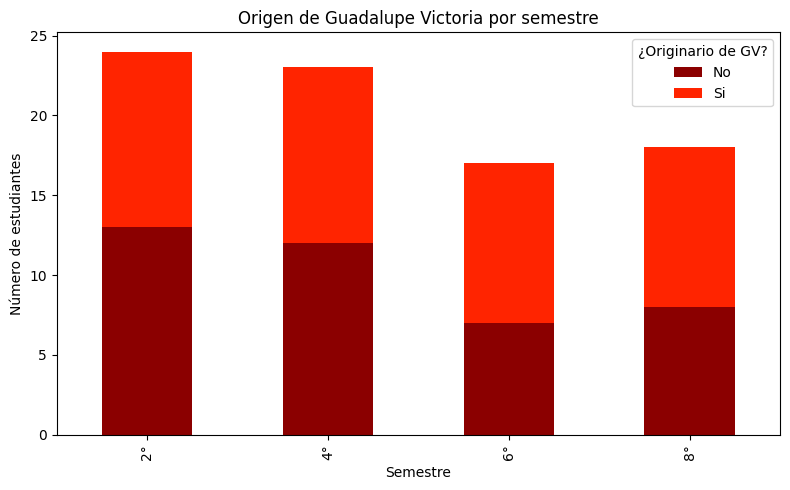

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Seleccionar columnas (Semestre y respuesta Sí/No)
tmp = df.iloc[:, [1, 2]].copy()

# Limpiar texto
tmp.iloc[:, 0] = tmp.iloc[:, 0].astype(str).str.strip()  # semestre
tmp.iloc[:, 1] = tmp.iloc[:, 1].astype(str).str.strip()  # Sí/No

# Crear tabla cruzada
tabla = pd.crosstab(tmp.iloc[:, 0], tmp.iloc[:, 1])

# Gráfica de barras apiladas estilo rojo lava
tabla.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=["#8B0000", "#FF2400"]  # rojo oscuro lava y rojo magma brillante
)

plt.title("Origen de Guadalupe Victoria por semestre")
plt.xlabel("Semestre")
plt.ylabel("Número de estudiantes")
plt.legend(title="¿Originario de GV?")
plt.tight_layout()

plt.show()

In [16]:
p3 = df.iloc[:, 3].astype(str).str.strip()
p3 = p3.replace({"nan": pd.NA}).dropna()

tabla_p3 = p3.value_counts().to_frame("conteo")
tabla_p3["%"] = (tabla_p3["conteo"] / tabla_p3["conteo"].sum() * 100).round(1)

print(tabla_p3)

                                      conteo     %
El Tecnológico de los Llanos fue tu:              
1er opcion                                40  48.8
2da opcion                                30  36.6
3er opción o más                          12  14.6


In [17]:
p3 = df.iloc[:, 3].astype(str).str.strip()
p3 = p3.replace({"nan": pd.NA}).dropna()

tabla_p3 = p3.value_counts().to_frame("conteo")
tabla_p3["%"] = (tabla_p3["conteo"] / tabla_p3["conteo"].sum() * 100).round(1)

print(tabla_p3)

                                      conteo     %
El Tecnológico de los Llanos fue tu:              
1er opcion                                40  48.8
2da opcion                                30  36.6
3er opción o más                          12  14.6


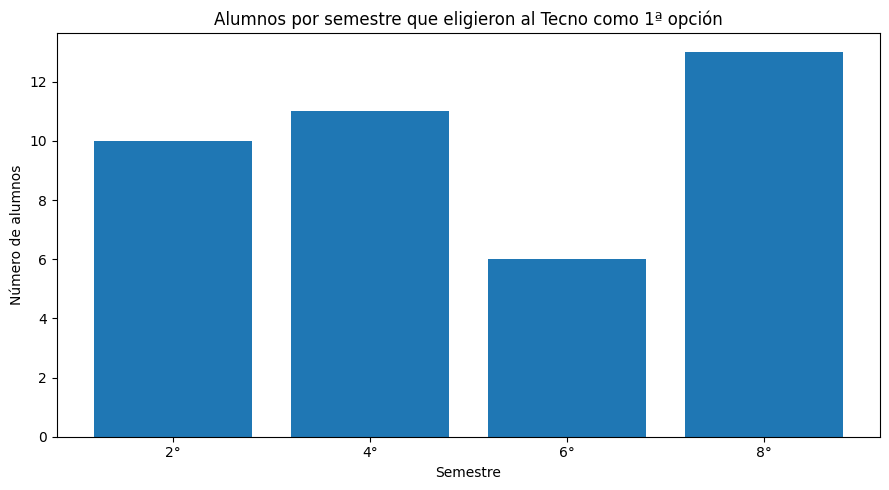

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Tomar semestre y respuesta
tmp = df.iloc[:, [1, 3]].copy()
tmp.iloc[:, 0] = tmp.iloc[:, 0].astype(str).str.strip()   # semestre
tmp.iloc[:, 1] = tmp.iloc[:, 1].astype(str).str.strip()   # respuesta
tmp = tmp.replace({"nan": pd.NA}).dropna()

# Detectar si fue 1ra opción
tmp["primera_opcion"] = tmp.iloc[:, 1].str.contains("1", na=False)

# Contar SOLO los que sí eligieron 1ra opción por semestre
conteo_semestre = (
    tmp[tmp["primera_opcion"]]
    .groupby(tmp.iloc[:, 0])
    .size()
    .sort_index()
)

# Gráfica
plt.figure(figsize=(9, 5))
plt.bar(conteo_semestre.index, conteo_semestre.values)
plt.title("Alumnos por semestre que eligieron al Tecno como 1ª opción")
plt.xlabel("Semestre")
plt.ylabel("Número de alumnos")
plt.tight_layout()
plt.show()

In [19]:
p4 = df.iloc[:, 4].astype(str).str.strip()
p4 = p4.replace({"":pd.NA,"nan":pd.NA}).dropna()

# separar opciones 

opciones = p4.str.split(";").explode().astype(str).str.strip()
opciones = opciones.replace({"":pd.NA, "nan": pd.NA}).dropna()

tabla_p4 = opciones.value_counts().to_frame("conteo")
tabla_p4["%"] = (tabla_p4["conteo"]/tabla_p4["conteo"].sum()*100).round(1)
print(tabla_p4)

                                                    conteo     %
¿Por qué elegiste esta institución? (elige máxi...              
Cercanía a mi domicilio                                 56  28.9
Recomendación de familiares y amigos                    37  19.1
Costo accesible                                         30  15.5
Oferta de la carrera                                    22  11.3
Prestigio académico                                     15   7.7
Instalaciones                                           11   5.7
No fui aceptado en otra institución                      9   4.6
Becas disponibles                                        6   3.1
Otra                                                     5   2.6
Actividades extracurriculares                            3   1.5


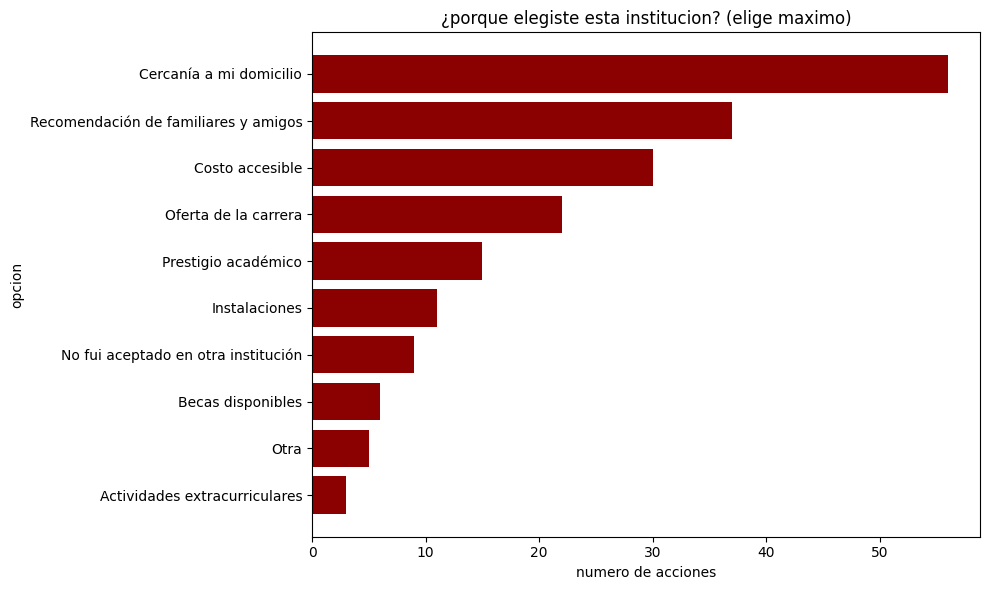

In [20]:
tabla_plot = tabla_p4.sort_values("conteo", ascending = True)
plt.figure(figsize=(10,6))
plt.barh(tabla_plot.index, tabla_plot["conteo"], color = ["#8B0000FF"])
plt.title("¿porque elegiste esta institucion? (elige maximo)")
plt.xlabel("numero de acciones")
plt.ylabel("opcion")
plt.tight_layout()
plt.show()

### Actividad: obtener una grafica similar a la siguiente a partir de los datos 

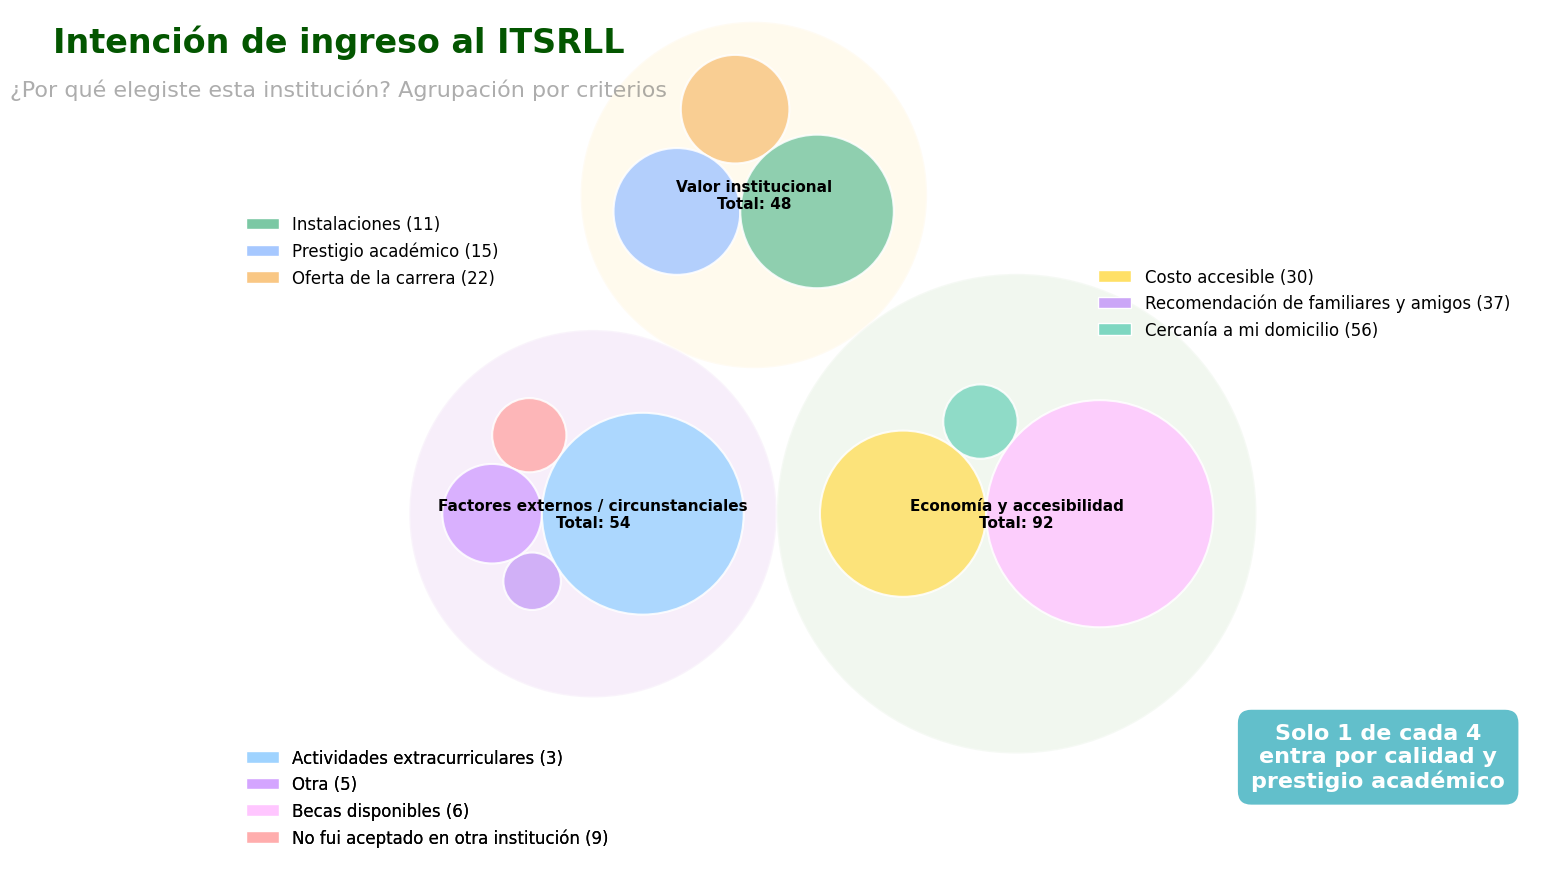

In [21]:
from matplotlib.patches import Circle, Patch
import circlify

# Columna de la pregunta 4 (según tu notebook)
col_p4 = "¿Por qué elegiste esta institución? (elige máximo 3)"

# Limpiar y separar respuestas múltiples
p4 = df[col_p4].astype(str).str.strip()
p4 = p4.replace({"": pd.NA, "nan": pd.NA}).dropna()

opciones = p4.str.split(";").explode().astype(str).str.strip()
opciones = opciones.replace({"": pd.NA, "nan": pd.NA}).dropna()

# Conteo por opción
tabla_p4 = opciones.value_counts().to_frame("conteo")
tabla_p4["porcentaje"] = (tabla_p4["conteo"] / tabla_p4["conteo"].sum() * 100).round(1)


# AGRUPACIÓN POR CRITERIOS
grupo_map = {
    "Cercanía a mi domicilio": "Economía y accesibilidad",
    "Costo accesible": "Economía y accesibilidad",
    "Becas disponibles": "Economía y accesibilidad",

    "Recomendación de familiares y amigos": "Factores externos / circunstanciales",
    "No fui aceptado en otra institución": "Factores externos / circunstanciales",
    "Otra": "Factores externos / circunstanciales",
    "Actividades extracurriculares": "Factores externos / circunstanciales",

    "Instalaciones": "Valor institucional",
    "Prestigio académico": "Valor institucional",
    "Oferta de la carrera": "Valor institucional",
}

# Armar dataframe de detalle (robusto)
detalle = tabla_p4.reset_index()
detalle = detalle.rename(columns={detalle.columns[0]: "opcion"})
detalle["grupo"] = detalle["opcion"].map(grupo_map).fillna("Sin clasificar")

# Totales por grupo
grupos = (
    detalle.groupby("grupo", as_index=False)["conteo"]
    .sum()
    .rename(columns={"conteo": "total_grupo"})
)

# Orden para que se acomoden visualmente mejor
orden_grupos = [
    "Valor institucional",
    "Factores externos / circunstanciales",
    "Economía y accesibilidad",
    "Sin clasificar"
]

grupos["orden"] = grupos["grupo"].apply(lambda x: orden_grupos.index(x) if x in orden_grupos else 999)
grupos = grupos.sort_values("orden").reset_index(drop=True)


# COLORES
color_opcion = {
    "Instalaciones": "#7BC8A4",
    "Prestigio académico": "#A6C8FF",
    "Oferta de la carrera": "#F9C784",

    "Costo accesible": "#FFE066",
    "Recomendación de familiares y amigos": "#CBA6F7",
    "Cercanía a mi domicilio": "#7ED7C1",

    "Actividades extracurriculares": "#9FD3FF",
    "Otra": "#D4A5FF",
    "Becas disponibles": "#FFC6FF",
    "No fui aceptado en otra institución": "#FFADAD",
}

# COLORES GRUPOS (burbujas grandes)
color_grupo = {
    "Valor institucional": "#FFF2CC",
    "Factores externos / circunstanciales": "#EAD1F2",
    "Economía y accesibilidad": "#D9EAD3",
    "Sin clasificar": "#EEEEEE",
}


# LAYOUT DE BURBUJAS GRANDES (GRUPOS)
# Valores para las burbujas principales
group_values = grupos["total_grupo"].tolist()

# Generar círculos empaquetados
circles_main = circlify.circlify(
    group_values,
    show_enclosure=False,
    target_enclosure=circlify.Circle(x=0, y=0, r=1)
)

# Convertir a dataframe
main_layout = []
for grp, c in zip(grupos.itertuples(index=False), circles_main):
    main_layout.append({
        "grupo": grp.grupo,
        "total": grp.total_grupo,
        "x": c.x,
        "y": c.y,
        "r": c.r
    })

main_layout = pd.DataFrame(main_layout)


# GRAFICAR
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_aspect("equal")
ax.axis("off")

# Margen visual
ax.set_xlim(-1.45, 1.65)
ax.set_ylim(-1.0, 1.0)

# Dibujar burbujas de grupo
for row in main_layout.itertuples(index=False):
    circle = Circle(
        (row.x, row.y), row.r,
        facecolor=color_grupo.get(row.grupo, "#EAEAEA"),
        edgecolor="white",
        linewidth=2,
        alpha=0.35
    )
    ax.add_patch(circle)

    # Texto del grupo
    ax.text(
        row.x, row.y,
        f"{row.grupo}\nTotal: {row.total}",
        ha="center", va="center",
        fontsize=11, weight="bold", color="#000000"
    )


# SUB-BURBUJAS DENTRO DE CADA GRUPO
for row in main_layout.itertuples(index=False):
    sub = detalle[detalle["grupo"] == row.grupo].copy()

    if len(sub) == 0:
        continue

    # subcircles en un sistema local (centro 0,0 radio ~1)
    sub_circles = circlify.circlify(
        sub["conteo"].tolist(),
        show_enclosure=False,
        target_enclosure=circlify.Circle(x=0, y=0, r=1)
    )

    # Escalar y trasladar al círculo principal
    scale = row.r * 0.82

    for sub_row, sc in zip(sub.itertuples(index=False), sub_circles):
        sx = row.x + sc.x * scale
        sy = row.y + sc.y * scale
        sr = sc.r * scale

        c = Circle(
            (sx, sy), sr,
            facecolor=color_opcion.get(sub_row.opcion, "#999999FF"),
            edgecolor="white",
            linewidth=1.5,
            alpha=0.85
        )
        ax.add_patch(c)


# TÍTULOS
ax.text(
    0.1, 0.95, "Intención de ingreso al ITSRLL",
    transform=ax.transAxes, ha="center",
    fontsize=24, weight="bold", color="#035600"
)

ax.text(
    0.1, 0.90, "¿Por qué elegiste esta institución? Agrupación por criterios",
    transform=ax.transAxes, ha="center",
    fontsize=16, color="#5555557B"
)


# LEYENDAS
leyenda_valor = ["Instalaciones", "Prestigio académico", "Oferta de la carrera"]
leyenda_econ = ["Costo accesible", "Recomendación de familiares y amigos", "Cercanía a mi domicilio"]
leyenda_fact = ["Actividades extracurriculares", "Otra", "Becas disponibles", "No fui aceptado en otra institución"]

handles_izq = [
    Patch(facecolor=color_opcion[k], edgecolor="white",
          label=f"{k} ({int(tabla_p4.loc[k, 'conteo'])})")
    for k in leyenda_valor if k in tabla_p4.index
]

handles_der = [
    Patch(facecolor=color_opcion[k], edgecolor="white",
          label=f"{k} ({int(tabla_p4.loc[k, 'conteo'])})")
    for k in leyenda_econ if k in tabla_p4.index
]

handles_inf = [
    Patch(facecolor=color_opcion[k], edgecolor="white",
          label=f"{k} ({int(tabla_p4.loc[k, 'conteo'])})")
    for k in leyenda_fact if k in tabla_p4.index
]

leg1 = ax.legend(
    handles=handles_izq,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.78),
    frameon=False,
    fontsize=12
)
ax.add_artist(leg1)

leg2 = ax.legend(
    handles=handles_der,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.72),
    frameon=False,
    fontsize=12
)
ax.add_artist(leg2)

leg3 = ax.legend(
    handles=handles_inf,
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),
    frameon=False,
    fontsize=12
)
ax.add_artist(leg3)


# MENSAJE DESTACADO 
total = int(tabla_p4["conteo"].sum())
valor_total = grupos.loc[grupos["grupo"] == "Valor institucional", "total_grupo"]
valor_total = int(valor_total.iloc[0]) if len(valor_total) else 0

if valor_total > 0:
    razon = max(1, round(total / valor_total))
    frase = f"Solo 1 de cada {razon}\nentra por calidad y\nprestigio académico"
else:
    frase = "Nadie entra por calidad y\nprestigio académico"

ax.text(
    1.25, -0.72, frase,
    ha="center", va="center",
    fontsize=16, color="white", weight="bold",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#5ABCC9", edgecolor="none", alpha=0.95)
)

plt.tight_layout()
plt.show()

In [22]:
import pandas as pd

# métricas del dataset
registros = df.shape[0]
variables = df.shape[1]
nulos_totales = df.isnull().sum().sum()
duplicados = df.duplicated().sum()

# matriz de calidad
matriz_calidad = pd.DataFrame({

"Criterio":[
"Completitud",
"Consistencia",
"Validez",
"Actualidad",
"Representatividad"
],

"Estado actual":[
"Se detectaron algunos valores faltantes en ciertas preguntas de la encuesta.",
"No se encontraron registros duplicados y los formatos de respuesta son similares.",
"La mayoría de las respuestas pertenecen al dominio esperado de una encuesta.",
"Los datos corresponden a una encuesta reciente aplicada a estudiantes.",
"La muestra incluye 82 estudiantes, lo que representa parcialmente a la población."
],

"Evidencia encontrada":[
f"{nulos_totales} valores nulos detectados en el dataset",
f"{duplicados} registros duplicados encontrados",
"Revisión de valores únicos en las variables categóricas",
f"Dataset con {registros} registros y {variables} variables",
"Participación de estudiantes de varios semestres"
],

"Nivel de riesgo":[
"Medio",
"Bajo",
"Bajo",
"Bajo",
"Medio"
],

"Acción correctiva sugerida":[
"Completar valores faltantes o aplicar imputación de datos.",
"Normalizar texto y verificar categorías.",
"Validar rangos y categorías antes de entrenar modelos.",
"Actualizar el dataset periódicamente.",
"Recolectar más datos para mejorar la representatividad."
]

})

matriz_calidad

,Criterio,Estado actual,Evidencia encontrada,Nivel de riesgo,Acción correctiva sugerida
0,Completitud,Se detectaron algunos valores faltantes en cie...,0 valores nulos detectados en el dataset,Medio,Completar valores faltantes o aplicar imputaci...
1,Consistencia,No se encontraron registros duplicados y los f...,0 registros duplicados encontrados,Bajo,Normalizar texto y verificar categorías.
2,Validez,La mayoría de las respuestas pertenecen al dom...,Revisión de valores únicos en las variables ca...,Bajo,Validar rangos y categorías antes de entrenar ...
3,Actualidad,Los datos corresponden a una encuesta reciente...,Dataset con 82 registros y 27 variables,Bajo,Actualizar el dataset periódicamente.
4,Representatividad,"La muestra incluye 82 estudiantes, lo que repr...",Participación de estudiantes de varios semestres,Medio,Recolectar más datos para mejorar la represent...


In [23]:
df.shape
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 27 columns):
 #   Column                                                       Non-Null Count  Dtype
---  ------                                                       --------------  -----
 0   ID                                                           82 non-null     int64
 1   Tu Semestre Actual                                           82 non-null     str  
 2   Eres originario de Guadalupe Victoria?                       82 non-null     str  
 3   El Tecnológico de los Llanos fue tu:                         82 non-null     str  
 4   ¿Por qué elegiste esta institución? (elige máximo 3)         82 non-null     str  
 5   Si no fue tu primera opción, ¿cuál fue el motivo principal?  82 non-null     str  
 6   Ingeniería Mecatrónica fue tu:                               82 non-null     str  
 7   Motivo principal para elegir Mecatrónica                     82 non-null     str  
 8   Antes de ingresar, tu c

,ID,Tu Semestre Actual,Eres originario de Guadalupe Victoria?,El Tecnológico de los Llanos fue tu:,¿Por qué elegiste esta institución? (elige máximo 3),"Si no fue tu primera opción, ¿cuál fue el motivo principal?",Ingeniería Mecatrónica fue tu:,Motivo principal para elegir Mecatrónica,"Antes de ingresar, tu conocimiento sobre la carrera era:",Percepcion de Calidad académica general de la carrera,...,Participación en concursos de robótica/tecnología,Participación en proyectos de investigación,Que tan importante es para ti los Deportes institucionales,Que tan importante es para ti las Actividades culturales,Que tan importante es para ti los Clubes estudiantiles,¿Has participado en alguna actividad extracurricular?,"Si no participas, el motivo principal es:",¿Has pensado en dejar la carrera?,Motivos que podrían llevarte a dejar la carrera (máximo 3):,Nivel de satisfacción general con la carrera:
0,1,8°,Si,2da opcion,Cercanía a mi domicilio;Recomendación de famil...,Decisión familiar,1er opción,Interés en Electrónica,Poco Claro,Buena,...,Importante,Algo Importante,Algo Importante,Importante,Importante,Si,No aplica,Una vez,Falta de motivación,Satisfecho
1,2,8°,No,1er opcion,Cercanía a mi domicilio;Costo accesible;Recome...,No aplica,2da opción,Campo laboral ampli,Poco Claro,Buena,...,Importante,Algo Importante,Algo Importante,Algo Importante,Muy Importante,No,No aplica,No aplica,Estrés o carga excesiva,Satisfecho
2,3,8°,No,1er opcion,Cercanía a mi domicilio;Recomendación de famil...,No aplica,1er opción,Interés en Electrónica,Poco Claro,Buena,...,Importante,Muy Importante,Importante,Muy Importante,Importante,Si,No aplica,Nunca,Problemas económicos,Satisfecho
3,4,8°,No,2da opcion,Cercanía a mi domicilio;,Cambié de interes,1er opción,Interés en Robótica,Poco Claro,Excelente,...,Importante,Importante,Algo Importante,Algo Importante,Importante,No,No aplica,No aplica,Problemas personales,Satisfecho
4,5,8°,Si,3er opción o más,Otra;,Motivos económicos,1er opción,Interés en Electrónica,Muy Limitado,Buena,...,Muy Importante,Muy Importante,Importante,Importante,Importante,Si,No aplica,Nunca,Cambio de intereses,Neutral


In [24]:
tabla_variables = pd.DataFrame({
"Variable": df.columns,
"Tipo de dato": df.dtypes,
"Valores únicos": [df[col].nunique() for col in df.columns]
})

tabla_variables

,Variable,Tipo de dato,Valores únicos
ID,ID,int64,82
Tu Semestre Actual,Tu Semestre Actual,str,4
Eres originario de Guadalupe Victoria?,Eres originario de Guadalupe Victoria?,str,2
El Tecnológico de los Llanos fue tu:,El Tecnológico de los Llanos fue tu:,str,3
¿Por qué elegiste esta institución? (elige máximo 3),¿Por qué elegiste esta institución? (elige máx...,str,47
"Si no fue tu primera opción, ¿cuál fue el motivo principal?","Si no fue tu primera opción, ¿cuál fue el moti...",str,6
Ingeniería Mecatrónica fue tu:,Ingeniería Mecatrónica fue tu:,str,3
Motivo principal para elegir Mecatrónica,Motivo principal para elegir Mecatrónica,str,10
"Antes de ingresar, tu conocimiento sobre la carrera era:","Antes de ingresar, tu conocimiento sobre la ca...",str,4
Percepcion de Calidad académica general de la carrera,Percepcion de Calidad académica general de la ...,str,3


In [25]:
faltantes = df.isnull().sum().reset_index()
faltantes.columns = ["Variable","Valores faltantes"]

faltantes

,Variable,Valores faltantes
0,ID,0
1,Tu Semestre Actual,0
2,Eres originario de Guadalupe Victoria?,0
3,El Tecnológico de los Llanos fue tu:,0
4,¿Por qué elegiste esta institución? (elige máx...,0
5,"Si no fue tu primera opción, ¿cuál fue el moti...",0
6,Ingeniería Mecatrónica fue tu:,0
7,Motivo principal para elegir Mecatrónica,0
8,"Antes de ingresar, tu conocimiento sobre la ca...",0
9,Percepcion de Calidad académica general de la ...,0


In [32]:
df.duplicated().sum()

for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

ID
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82]

Tu Semestre Actual
<StringArray>
['8°', '6°', '4°', '2°']
Length: 4, dtype: str

Eres originario de Guadalupe Victoria?
<StringArray>
['Si', 'No']
Length: 2, dtype: str

El Tecnológico de los Llanos fue tu:
<StringArray>
['2da opcion', '1er opcion', '3er opción o más ']
Length: 3, dtype: str

¿Por qué elegiste esta institución? (elige máximo 3)
<StringArray>
[                                     'Cercanía a mi domicilio;Recomendación de familiares y amigos;',
                      'Cercanía a mi domicilio;Costo accesible;Recomendación de familiares y amigos;',
                 'Cercanía a mi domicilio;Recomendación de familiares y amigos;Oferta de la carrera;',
                                                                           

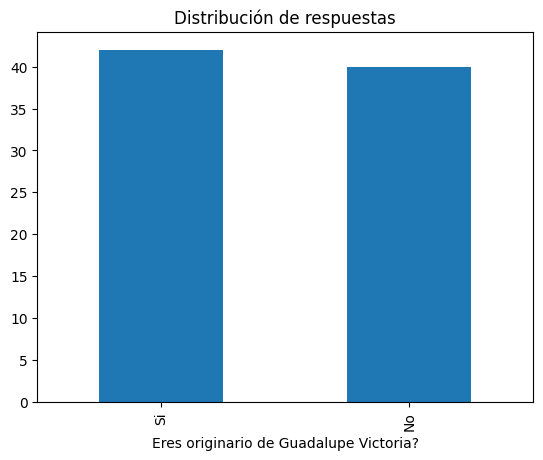

In [33]:
import matplotlib.pyplot as plt

df.iloc[:,2].value_counts().plot(kind="bar")
plt.title("Distribución de respuestas")
plt.show()